### Kernel timing

Cycles from control-CPU launch until the result is back in DRAM, for one kernel
on `x_bytes` of input:

```
ctrl->DMA | DRAM read | DRAM->SRAM | launch | COMPUTE | ctrl->DMA | SRAM->DRAM | DRAM write
```

`latency` = every stage serialised (one shot).
`pipelined` = chunked and double-buffered, so the slowest pipe hides the rest.

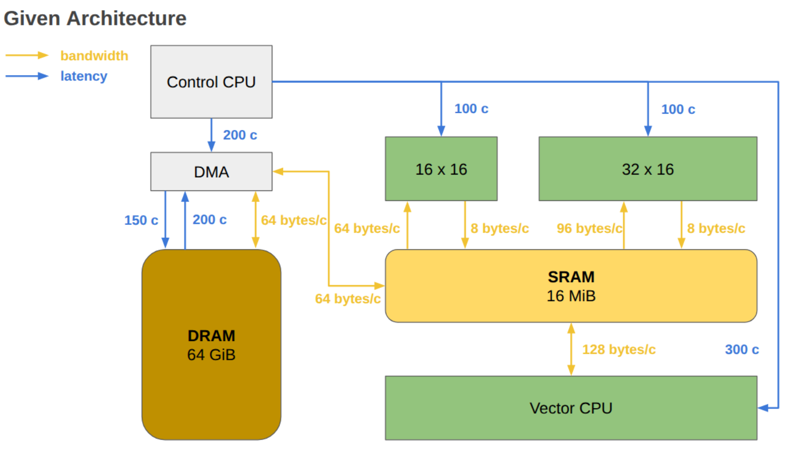

In [1]:
from PIL import Image
from IPython.display import display

img = Image.open("img/architecture.png")
width = 800
height = round(img.height * width / img.width)

display(img.resize((width, height)))

## 1 Compute bound/ Memory bound on SA units

With hardware architecture in hand, we are able to model latency, data transfer and computation wall as a function
of input byte, computation units and K in sa unit.

Model a full workflow: kernel start + DRAM -> SRAM -> SA1 & SA2 -> SRAM -> SRAM -> DRAM

In [2]:
## Latency model
BW_DMA = 64                                     # DRAM -> DMA -> SRAM
BW_VCPU = 128                                   # SRAM <-> vector CPU
PORTS = {"sa16": [(16, 64, 8)],                 # (rows, in B/cyc, out B/cyc)
         "sa32": [(32, 96, 8)],
         "both": [(16, 64, 8), (32, 96, 8)]}


def kernel_time(x_bytes, unit="both", K1=256, K2=None):
    """
    Cycles from control-CPU launch until the result is back in DRAM.

    K1 : contraction depth of the first array (the only array, unless unit="both")
    K2 : contraction depth of the second array ("both" only; defaults to K1)
    """
    LAT = 200 + 200 + 200 + 150  # Control-> DMA, DRAM read, control->DMA, DRAM write
    if unit == "vcpu":
        y = x_bytes
        compute = (x_bytes + y) / BW_VCPU
        launch = 300
    else:
        if K2 is None:
            K2 = K1
        ports = PORTS[unit]
        Ks = [K1, K2][:len(ports)]              # a single array uses K1 only

        # geometry and cost of ONE tile op on each array
        tiles = []
        for (rows, in_bw, out_bw), K in zip(ports, Ks):
            tin, tout = (rows + 16) * K, rows * 16 * 2      # bytes per tile op, in and out
            # pipelined array -> a tile costs max(in, out), never in + out
            cost = max(tin / in_bw, tout / out_bw)
            tiles.append((tin, tout, cost, tin / cost))     # tin/cost = EFFECTIVE B/cyc

        # Split by EFFECTIVE input rate, not nominal port width: an output-bound
        # array cannot consume at its port speed, so splitting by in_bw over-feeds
        # it and it finishes late.  With K1 != K2 the two arrays are almost always
        # bound differently, so this matters.
        tot_bw = sum(eff for _, _, _, eff in tiles)
        y = compute = 0.0
        for tin, tout, cost, eff in tiles:
            xi = x_bytes * eff / tot_bw         # now both arrays really do finish together
            n = xi / tin                        # number of tile ops
            y += n * tout
            compute = max(compute, n * cost)    # arrays run concurrently -> max

        launch = 100

    load, store = x_bytes / BW_DMA, y / BW_DMA
    return {"load": load, "compute": compute, "store": store, "out_bytes": y,
            "latency":   LAT + launch + load + compute + store,   # serial, one shot
            "pipelined": LAT + launch + max(load, compute, store)}  # double-buffered

Apply a grid search on the latency model

In [3]:
MB = 2 ** 20
GB = 2 ** 30

byte_list = [16 * MB]
device_list = ["sa16", "sa32", "both"]
K1_list = [32, 64, 128, 256]
K2_list = [32, 64, 128, 256]

print(f"{'size':>8} {'device':>7} {'K1/K2':>9} {'transfer':>12} {'compute':>12} "
      f"{'total':>13} {'transfer%':>10}")
print("-" * 78)

for x in byte_list:
    for unit in device_list:
        # both arrays -> sweep a depth for each; a single array has only K1
        pairs = ([(k1, k2) for k1 in K1_list for k2 in K2_list] if unit == "both"
                 else [(k1, None) for k1 in K1_list])
        for K1, K2 in pairs:
            r = kernel_time(x, unit, K1, K2)
            transfer = r["load"] + r["store"]      # DRAM->SRAM  +  SRAM->DRAM
            compute = r["compute"]
            total = r["latency"]                   # transfer + compute + LAT
            label = f"{K1}/{K2}" if K2 is not None else f"{K1}"
            print(f"{x // MB:>6}MB {unit:>7} {label:>9} {transfer:>12,.0f} {compute:>12,.0f} "
                  f"{total:>13,.0f} {100 * transfer / total:>9.2f}%")
        print("-" * 78)

    size  device     K1/K2     transfer      compute         total  transfer%
------------------------------------------------------------------------------
    16MB    sa16        32      393,216    1,048,576     1,442,642     27.26%
    16MB    sa16        64      327,680      524,288       852,818     38.42%
    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%
------------------------------------------------------------------------------
    16MB    sa32        32      436,907    1,398,101     1,835,858     23.80%
    16MB    sa32        64      349,525      699,051     1,049,426     33.31%
    16MB    sa32       128      305,835      349,525       656,210     46.61%
    16MB    sa32       256      283,989      174,763       459,602     61.79%
------------------------------------------------------------------------------
    16MB    both     32/32      411,941      599,186     1,01

### Conclusion


    16MB    both   256/256      281,805      104,858       387,512     72.72%

**1. The transfer proportion is a bottleneck readout.** 72.72% (both, K=256)
  means the kernel is transfer-dominated and widening DRAM would help.
  23.80% (sa32, K=32) means it's compute-dominated and DRAM is irrelevant.
  The proportion moves from 24% to 73% purely from choosing K and the device
  — same bytes, same work.

    16777216B      sa16  256    278,528.0    262,144.0    541,522.0     51.43%

The size column barely matters once past the fixed latency: 16 and 32MiB give nearly identical percentages (58.88 / 58.93),
  because both transfer and compute scale linearly. K and device are the
  real variables in this sweep; x mostly is not.

    16MB    sa16       128      294,912      262,144       557,906     52.86%
    16MB    sa16       256      278,528      262,144       541,522     51.43%

**2. The 8 B/c output port is the bottleneck.** Inputs come in at
  64–96 B/c and DMA at 64, but results leave at 8. the "compute" column is pure port time.

**3. K >= 128 Memory bound, <= computation bound**


## 2. 2 SA unit Parallelization

In the previous section we study the memory bound/

On-chip analysis. SA1 SA2 model!

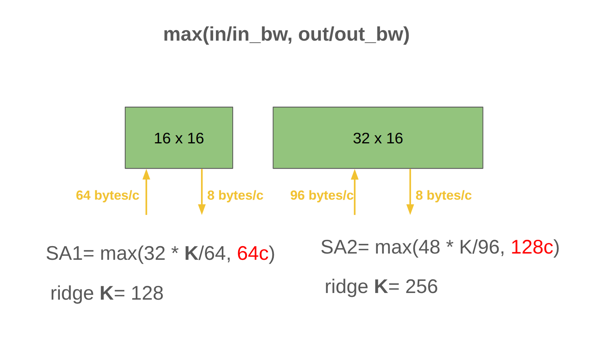

In [4]:
from PIL import Image
from IPython.display import display

img = Image.open("img/SA_ridge.png")
width = 600
height = round(img.height * width / img.width)

display(img.resize((width, height)))

In [5]:
class SA1:
    def __init__(self, rows, K):
        assert rows<= 16 and K <= 256
        self.BW_in = 64
        self.BW_out = 8
        self.rows = rows
        self.K = K

    def cycle(self):
        return max(self.rows * K * 2 * 1/self.BW_in, 16 * 16 * 2 /self.BW_out)

    def macs(self):
          return self.rows * 16 * self.K

    def mac_rate(self):
          return self.macs() / self.cycle()

class SA2:
  def __init__(self, rows, K):
      assert rows <= 32 and K <= 256
      self.BW_in = 96
      self.BW_out = 8
      self.rows = rows
      self.K = K

  def cycle(self):
      in_bytes = (self.rows + 16) * self.K * 1
      out_bytes = 32 * 16 * 2
      return max(in_bytes / self.BW_in, out_bytes / self.BW_out)

  def macs(self):
      return self.rows * 16 * self.K

  def mac_rate(self):
      return self.macs() / self.cycle()

class VCPU:
      """Vector CPU.  No tiles, no contraction depth: it just streams bytes.
      Infinite compute (per the spec), so the cost IS the traffic."""
      def __init__(self, in_bytes, out_bytes):
          self.BW = 128
          self.in_bytes = in_bytes
          self.out_bytes = out_bytes

      def cycle(self):
          return (self.in_bytes + self.out_bytes) / self.BW

In [17]:
for K in [32, 64, 128, 256]:
    print(f"K={K}")
    sa1 = SA1(16, K)
    print(f"sa1 macs: {sa1.macs()}, cycle:{sa1.cycle()}")

    sa2 = SA2(32, K)
    print(f"sa2 macs: {sa2.macs()}, cycle:{sa2.cycle()}")

    # vcpu_1 = VCPU(in_bytes=16 * K * 2 * 1 , out_bytes=16 * K * 2 * 1)
    # vcpu_2 = VCPU(in_bytes=(32 + 16) * K * 1 , out_bytes=32 * 16 * 2)
    # print(f"vcpu cycle 1: {vcpu_1.cycle()}, cycle 2: {vcpu_2.cycle()}")


K=32
sa1 macs: 8192, cycle:64.0
sa2 macs: 16384, cycle:128.0
K=64
sa1 macs: 16384, cycle:64.0
sa2 macs: 32768, cycle:128.0
K=128
sa1 macs: 32768, cycle:64.0
sa2 macs: 65536, cycle:128.0
K=256
sa1 macs: 65536, cycle:128.0
sa2 macs: 131072, cycle:128.0


### Conclusion

K=128   sa1 macs: 32768, cycle: 64.0   -> 512 MAC/cyc
      sa2 macs: 65536, cycle:128.0   -> 512 MAC/cyc     TIE

K=256   sa1 macs: 65536, cycle:128.0   -> 512 MAC/cyc
      sa2 macs:131072, cycle:128.0   -> 1024 MAC/cyc    sa2 is 2x

**sa2 has no advantage on K = 128, and a 2× advantage on k = 256.**